# Regresión lineal en Python: ejemplo completo

Este notebook presenta un flujo reproducible de regresión lineal supervisada utilizando un CSV incluido en el proyecto. El objetivo es predecir `ingresos` a partir de `edad`, `horas_estudio` y `experiencia`.

Se calculan **R², RMSE, MAE, Pearson y Bias**, y se incluyen visualizaciones y análisis de residuos.

## 1. Librerías

Se utiliza `pandas` para manipulación de datos, `numpy` para cálculo numérico, `matplotlib` y `seaborn` para visualización, `scikit-learn` para el modelo y `scipy` para Pearson.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

pd.set_option('display.precision', 4)

## 2. Carga del CSV

El fichero `datos_regresion.csv` está incluido en la misma carpeta que el notebook.

In [21]:
df = pd.read_csv('datos_regresion.csv')
print(f'Dimensiones: {df.shape}')
display(df.head())

Dimensiones: (20, 5)


,id,edad,horas_estudio,experiencia,ingresos
0,1,22,5,1,1850
1,2,25,6,2,2100
2,3,28,7,3,2350
3,4,30,8,4,2550
4,5,32,6,5,2450


## 3. Exploración inicial

Antes de entrenar el modelo comprobamos estructura, valores ausentes y estadísticos descriptivos.

In [22]:
print('Información:')
df.info()
print('\nValores ausentes:')
display(df.isnull().sum().to_frame('missing_values'))
print('\nEstadísticas descriptivas:')
display(df.describe())

Información:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             20 non-null     int64
 1   edad           20 non-null     int64
 2   horas_estudio  20 non-null     int64
 3   experiencia    20 non-null     int64
 4   ingresos       20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes

Valores ausentes:


,missing_values
id,0
edad,0
horas_estudio,0
experiencia,0
ingresos,0



Estadísticas descriptivas:


,id,edad,horas_estudio,experiencia,ingresos
count,20.0000,20.000,20.0000,20.0000,20.0000
mean,10.5000,40.200,9.7000,11.9500,3310.0000
std,5.9161,11.349,3.2783,8.9588,984.9659
min,1.0000,22.000,5.0000,1.0000,1850.0000
25%,5.7500,31.500,7.0000,4.7500,2487.5000
50%,10.5000,39.000,9.5000,9.5000,3175.0000
75%,15.2500,48.500,12.0000,17.7500,3987.5000
max,20.0000,60.000,16.0000,30.0000,5150.0000


## 4. Matriz de correlación

La matriz permite observar las relaciones lineales entre las variables.

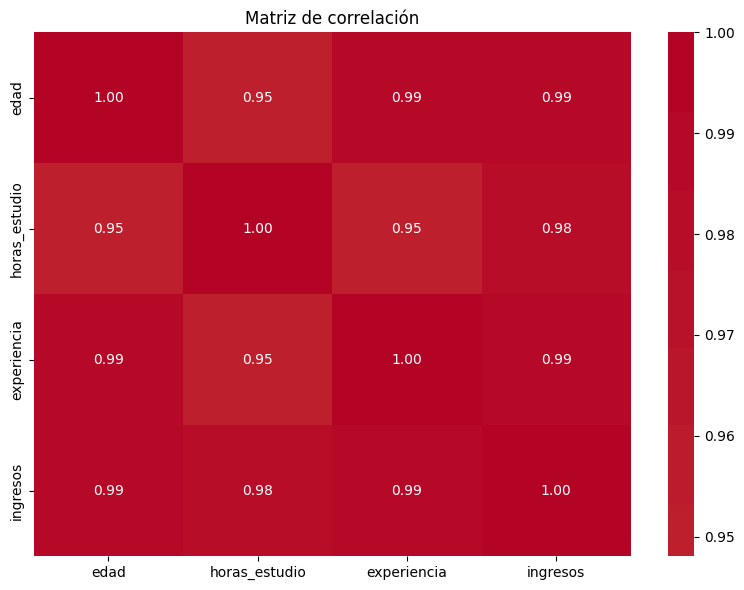

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns='id').corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## 5. Variables predictoras y objetivo

La regresión lineal múltiple se expresa como:

$$\hat{y}=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p$$

En este ejemplo, `ingresos` es la variable objetivo y `edad`, `horas_estudio` y `experiencia` son las variables predictoras.

In [24]:
features = ['edad', 'horas_estudio', 'experiencia']
target = 'ingresos'

X = df[features]
y = df[target]

print('Variables predictoras:', features)
print('Variable objetivo:', target)

Variables predictoras: ['edad', 'horas_estudio', 'experiencia']
Variable objetivo: ingresos


## 6. División entrenamiento/prueba

Se utiliza el 80 % de las observaciones para entrenamiento y el 20 % para evaluación. `random_state=42` permite reproducir la partición.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Tamaño entrenamiento: {len(X_train)}')
print(f'Tamaño prueba: {len(X_test)}')

Tamaño entrenamiento: 16
Tamaño prueba: 4


## 7. Entrenamiento del modelo

`LinearRegression` estima los coeficientes minimizando la suma de errores cuadráticos en el conjunto de entrenamiento.

In [38]:
def obtenermodelo(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)

    print(f'Intercepto: {model.intercept_:.4f}')

    coeficientes = pd.DataFrame({
        'variable': features,
        'coeficiente': model.coef_
    })
    display(coeficientes)
    return model
def hacerpredicciones(modelint,X_testint,y_testint):
    
    y_pred_int = modelint.predict(X_testint)
    resultados = pd.DataFrame({
    'real': y_testint.values,
    'predicho': y_pred_int,
    'error': y_testint.values - y_pred_int
    })

    display(resultados)
    return resultados,y_pred_int
def obtenermetricas(y_test,y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    pearson, pearson_pvalue = pearsonr(y_test, y_pred)
    bias = np.mean(y_test.to_numpy() - y_pred)

    metricas = pd.DataFrame({
        'Metrica': ['R2', 'RMSE', 'MAE', 'Pearson', 'Bias'],
        'Valor': [r2, rmse, mae, pearson, bias]
    })

    display(metricas)
    return metricas

model = obtenermodelo(X_train, y_train)
resultados,y_pred = hacerpredicciones(model,X_test,y_test)
print(X_test )
print(y_test)
print(y_pred)
metricas = obtenermetricas(y_test,y_pred)


X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.30, random_state=42
)
print(f'Tamaño entrenamiento: {len(X_train1)}')
print(f'Tamaño prueba: {len(X_test1)}')
model1 = obtenermodelo(X_train1, y_train1)
resultados1,y_pred1 = hacerpredicciones(model1,X_test1,y_test1)


print(X_test1 )
print(y_test1)
print(y_pred1)
metricas1 = obtenermetricas(y_test1,y_pred1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Tamaño entrenamiento: {len(X_train2)}')
print(f'Tamaño prueba: {len(X_test2)}')
model2 = obtenermodelo(X_train2, y_train2)
resultados2,y_pred2 = hacerpredicciones(model2,X_test2,y_test2)
metricas2 = obtenermetricas(y_test2,y_pred2)

Intercepto: 475.1180


,variable,coeficiente
0,edad,33.8155
1,horas_estudio,125.5915
2,experiencia,22.1393


,real,predicho,error
0,1850,1869.1550,-19.1550
1,2500,2580.8654,-80.8654
2,5150,5177.6897,-27.6897
3,2100,2118.3322,-18.3322


    edad  horas_estudio  experiencia
0     22              5            1
17    33              7            5
15    60             16           30
1     25              6            2
0     1850
17    2500
15    5150
1     2100
Name: ingresos, dtype: int64
[1869.15497546 2580.8653551  5177.68966786 2118.33220321]


,Metrica,Valor
0,R2,0.9989
1,RMSE,44.7462
2,MAE,36.5106
3,Pearson,0.9998
4,Bias,-36.5106


...

,Metrica,Valor
0,R2,0.9989
1,RMSE,37.0145
2,MAE,28.4146
3,Pearson,0.9996
4,Bias,-21.8694


Tamaño entrenamiento: 16
Tamaño prueba: 4
Intercepto: 475.1180


,variable,coeficiente
0,edad,33.8155
1,horas_estudio,125.5915
2,experiencia,22.1393


,real,predicho,error
0,1850,1869.1550,-19.1550
1,2500,2580.8654,-80.8654
2,5150,5177.6897,-27.6897
3,2100,2118.3322,-18.3322


,Metrica,Valor
0,R2,0.9989
1,RMSE,44.7462
2,MAE,36.5106
3,Pearson,0.9998
4,Bias,-36.5106


## 8. Predicciones

Se predicen los valores del conjunto de prueba, que no fue utilizado para ajustar el modelo.

In [15]:
y_pred = model.predict(X_test)

resultados = pd.DataFrame({
    'real': y_test.values,
    'predicho': y_pred,
    'error': y_test.values - y_pred
})

display(resultados)

,real,predicho,error
0,1850,1869.1550,-19.1550
1,2500,2580.8654,-80.8654
2,5150,5177.6897,-27.6897
3,2100,2118.3322,-18.3322


## 9. Métricas de evaluación

**R²** mide la proporción de variabilidad explicada por el modelo.

**RMSE** cuantifica el error cuadrático medio en las mismas unidades de la variable objetivo:

$$RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}$$

**MAE** es el error absoluto medio:

$$MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$$

**Pearson** mide la correlación lineal entre valores reales y predichos.

**Bias** se define como el error medio `real - predicho`:

$$Bias=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)$$

In [16]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
pearson, pearson_pvalue = pearsonr(y_test, y_pred)
bias = np.mean(y_test.to_numpy() - y_pred)

metricas = pd.DataFrame({
    'Metrica': ['R2', 'RMSE', 'MAE', 'Pearson', 'Bias'],
    'Valor': [r2, rmse, mae, pearson, bias]
})

display(metricas)

,Metrica,Valor
0,R2,0.9989
1,RMSE,44.7462
2,MAE,36.5106
3,Pearson,0.9998
4,Bias,-36.5106


## 10. Valores reales frente a predicciones

La diagonal representa la situación ideal `real = predicho`. Los puntos próximos a ella corresponden a errores pequeños.

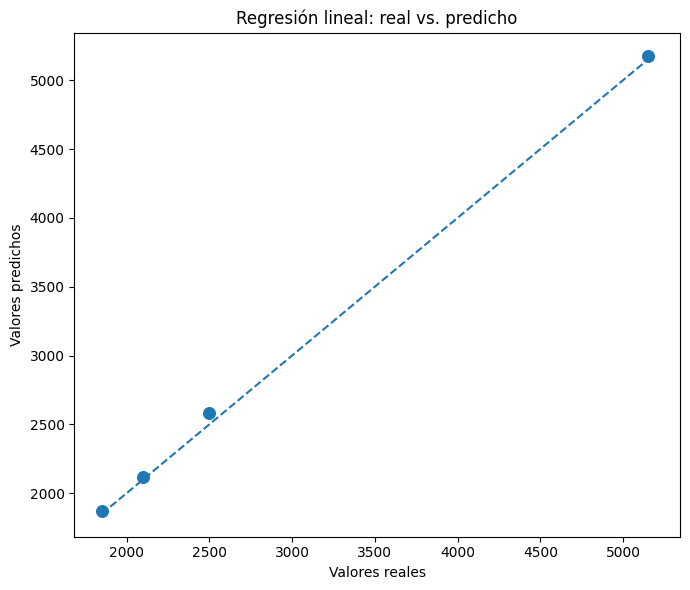

In [17]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, s=70)
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], '--')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Regresión lineal: real vs. predicho')
plt.tight_layout()
plt.show()

## 11. Análisis de residuos

El residuo se define como:

$$e_i=y_i-\hat{y}_i$$

Una distribución de residuos sin patrones sistemáticos es una señal favorable, aunque un diagnóstico completo requiere también analizar residuos frente a predicciones y otros supuestos del modelo.

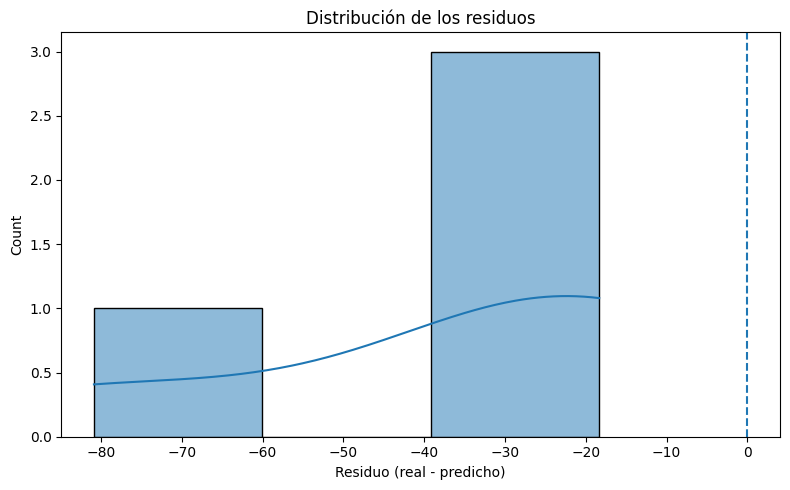

In [18]:
residuos = y_test.to_numpy() - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuos, kde=True)
plt.axvline(0, linestyle='--')
plt.xlabel('Residuo (real - predicho)')
plt.title('Distribución de los residuos')
plt.tight_layout()
plt.show()

## 12. Resumen final

El flujo completo es:

**CSV → exploración → selección de variables → train/test split → regresión lineal → predicción → métricas → análisis de residuos.**

El notebook puede reutilizarse con otro CSV modificando `features` y `target`.

In [19]:
print('===== RESULTADOS DEL MODELO =====')
print(f'R²      : {r2:.4f}')
print(f'RMSE    : {rmse:.4f}')
print(f'MAE     : {mae:.4f}')
print(f'Pearson : {pearson:.4f}')
print(f'Bias    : {bias:.4f}')

===== RESULTADOS DEL MODELO =====
R²      : 0.9989
RMSE    : 44.7462
MAE     : 36.5106
Pearson : 0.9998
Bias    : -36.5106
